**Filtering and Downsampling** <br>
This notebook serves the correction and rejection of artefacts in the EEG data. Independent Component Analysis (ICA) will be performed on the continuous data and the autoreject function on epoched data.

[] Adjust with better pre-processed behavioral data, that is in the UGR server

In [ ]:
# 1. Imports
import numpy as np
import mne
from mne_bids import BIDSPath, read_raw_bids
from pathlib import Path
import os
import pandas as pd
from autoreject import AutoReject, get_rejection_threshold

# 2. Configuration
deriv_root = Path(r"C:\Users\noahm\projects\loc_analysis\data\derivatives")

sub_number = "14"
task = "loc"
description = "filtResamp250"

# Subject folder
sub_dir = deriv_root / f"sub-{sub_number}" / "eeg"

# Input: filtered + downsampled recording
fname_input = (
    sub_dir
    / f"sub-{sub_number}_task-{task}_desc-{description}_eeg.fif"
)

# Output: cleaned recording
fname_cleaned = (
    sub_dir
    / f"sub-{sub_number}_task-{task}_desc-cleanEpochs_eeg.fif"
)

print(f"Working on Subject: {sub_number}")
print(f"Input file:   {fname_input}")
print(f"Output file:  {fname_cleaned}")

# 3. Loading the data

# Check if cleaned file already exists
# if fname_cleaned.exists():
#     print("Found existing cleaned file. Loading...")
#     raw_eeg = mne.io.read_raw_fif(fname_cleaned, preload=True)

# else:
#     print("Loading filtered/downsampled file...")
#     raw_eeg = mne.io.read_raw_fif(fname_input, preload=True)

raw_eeg = mne.io.read_raw_fif(fname_input, preload=True)

# Extract events from annotations
events, event_id = mne.events_from_annotations(
    raw_eeg,
    verbose=False
)

Working on Subject: 14
Input file:   C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_desc-filtResamp250_eeg.fif
Output file:  C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_desc-cleanEpochs_eeg.fif
Opening raw data file C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_desc-filtResamp250_eeg.fif...
    Range : 0 ... 555779 =      0.000 ...  2223.116 secs
Ready.
Reading 0 ... 555779  =      0.000 ...  2223.116 secs...


### Steps 5 & 6: Preliminary Epoching & ICA


In [4]:
# ==========================================
# SCHRITT 5 & 6: Preliminary Epoching & ICA
# ==========================================
print("Create preliminary epochs for ICA fitting...")
# Für die ICA nutzen wir oft 1-Sekunden-Epochen ohne große Überlappung
tstep = 1.0
events_ica = mne.make_fixed_length_events(raw_eeg, duration=tstep)
epochs_ica = mne.Epochs(raw_eeg, events_ica, tmin=0.0, tmax=tstep, baseline=None, preload=True)

# Leichter Artefakt-Screen, um extreme Ausreißer vor der ICA zu verwerfen
# (ICA reagiert empfindlich auf extreme, seltene Artefakte)
reject_ica = get_rejection_threshold(epochs_ica)
epochs_ica.drop_bad(reject=reject_ica)

print("Führe ICA durch...")
# n_components leicht anpassen (meistens nutzt man nicht 100% der Kanäle)
ica = mne.preprocessing.ICA(n_components=0.99, random_state=42, method='picard')
ica.fit(epochs_ica)

Create preliminary epochs for ICA fitting...
Not setting metadata
2223 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2223 events and 251 original time points ...
0 bad epochs dropped
Estimating rejection dictionary for eeg
Estimating rejection dictionary for eog
    Rejecting  epoch based on EEG : ['AF7']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AF7', 'AF8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AF8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AF7', 'AF8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AF8']
    Rejecting  epoch based on EEG : ['F3', 'TP9', 'CP5', 'P7', 'TP7', 'P5', 'PO7']
    Rejecting  epoch based on EEG : ['F3', 'P7']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AF8']
    Rejecting  epoch based on EEG : ['F3', 'P7']
    Rejecting  epoch based on EEG : ['Fp1', 'P7', 'Fp2']
    Rejecting  epoch based on EEG : ['F3', 'P7']
    Rejecting  epoch based on EE

Method,picard
Fit parameters,max_iter=500
Fit,63 iterations on epochs (334834 samples)
ICA components,45
Available PCA components,63
Channel types,eeg
ICA components marked for exclusion,—


In [5]:
# ==========================================
# SCHRITT 7: Identifying and removing non-brain components
# ==========================================
print("Identifiziere EOG/ECG Artefakte...")
# Falls du EOG/ECG Kanäle hast, kann MNE diese automatisch finden:
eog_indices, eog_scores = ica.find_bads_eog(raw_eeg)
ica.exclude = eog_indices

Identifiziere EOG/ECG Artefakte...
Using EOG channels: HEOG, VEOG
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.5

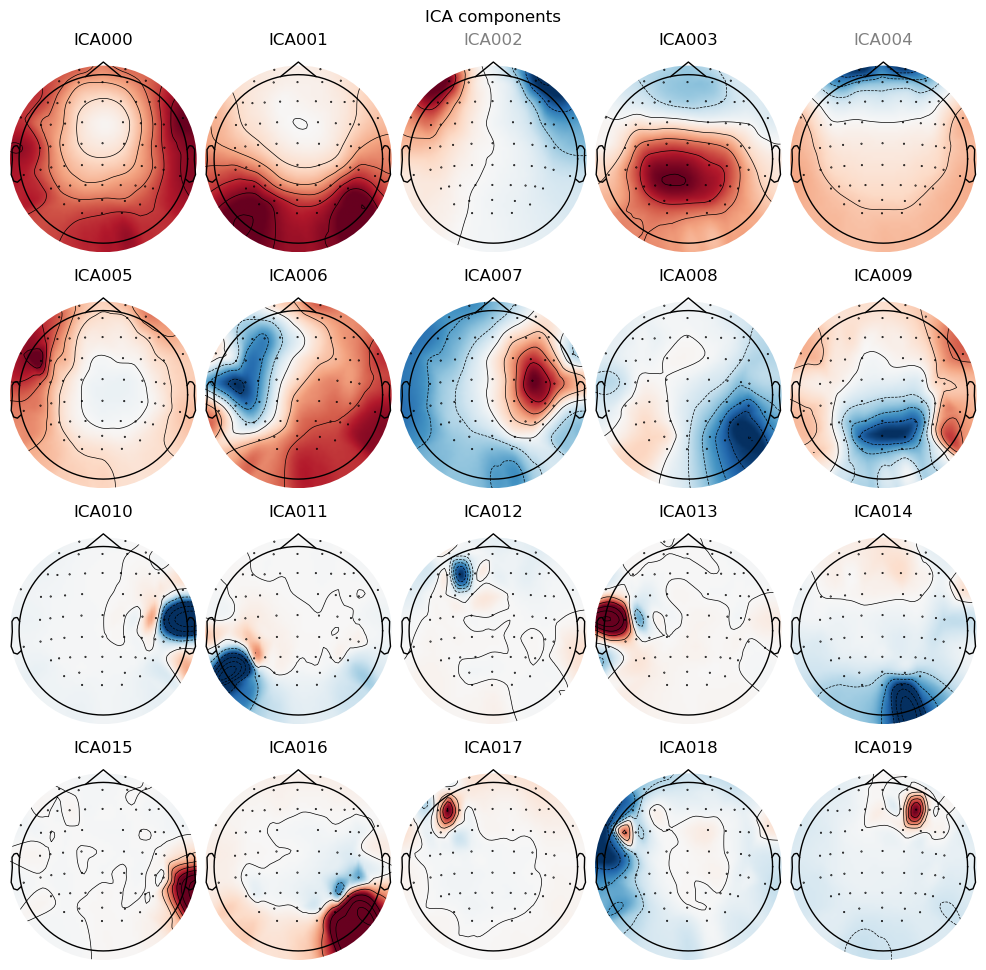

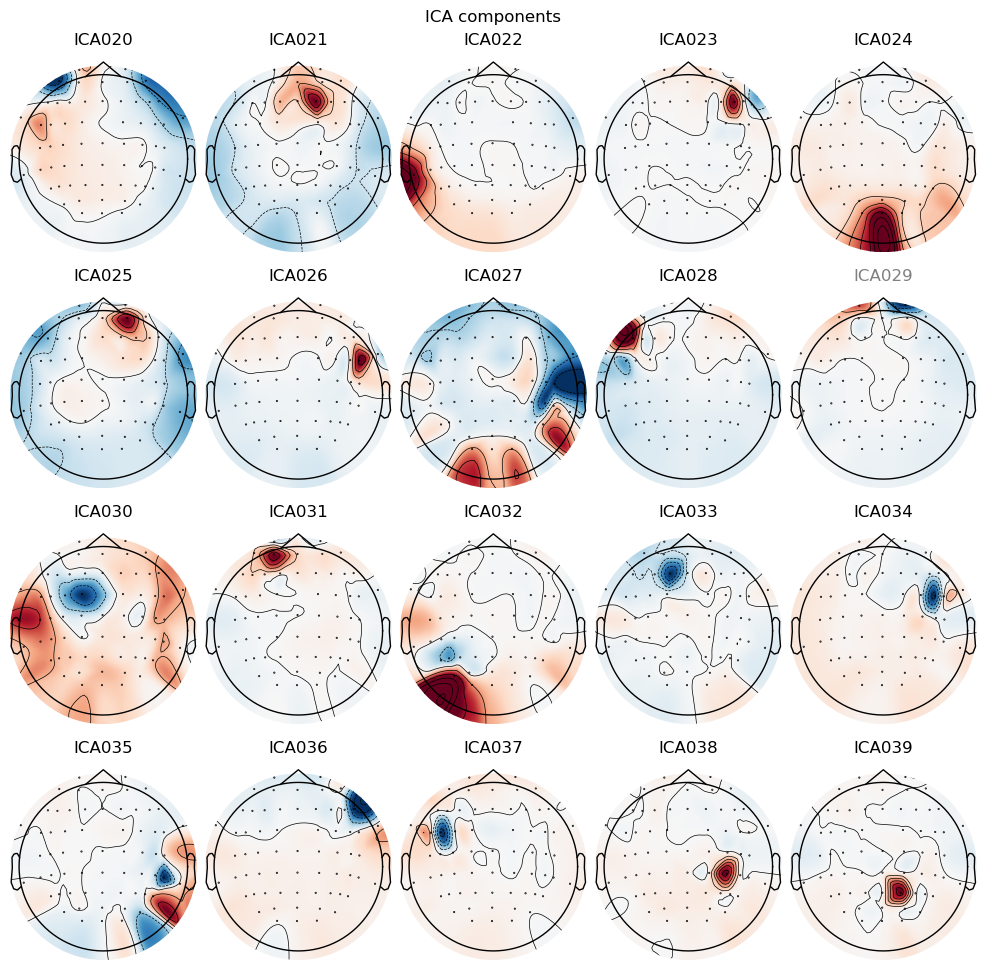

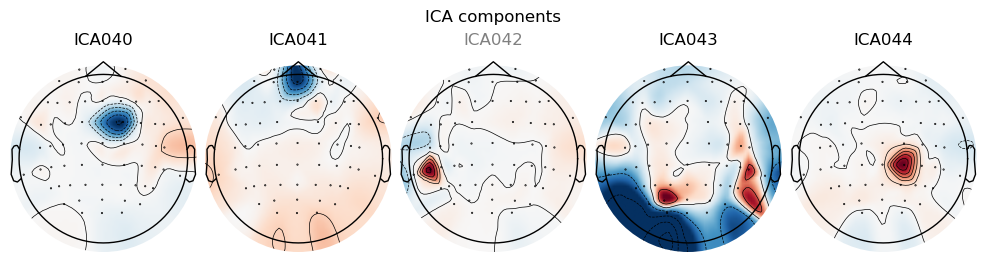

[<MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x260.5 with 5 Axes>]

In [6]:
# Alternativ/Zusätzlich: Visuelle Inspektion im Jupyter Notebook!
# Führe dies in einer eigenen Zelle aus:
ica.plot_components()
# ica.plot_sources(raw_eeg)

In [7]:
# Wir nehmen für das Gerüst an, dass Komponenten 0 und 1 Blinzeln sind:
ica.exclude = [2, 4]  # Diese Liste nach deiner visuellen Inspektion anpassen!

print("Wende ICA auf die kontinuierlichen Raw-Daten an...")
raw_clean = raw_eeg.copy()
ica.apply(raw_clean)

Wende ICA auf die kontinuierlichen Raw-Daten an...
Applying ICA to Raw instance
    Transforming to ICA space (45 components)
    Zeroing out 2 ICA components
    Projecting back using 63 PCA components


<Raw | sub-14_task-loc_desc-filtResamp250_eeg.fif, 65 x 555780 (2223.1 s), ~275.7 MiB, data loaded>

In [ ]:
# ==========================================
# SCHRITT 8: Final epoching
# ==========================================
# print("Erstelle finale Epochen...")
# # Hier setzt du deine tatsächlichen Trigger, tmin und tmax ein
# tmin = -0.2  # 200ms vor Stimulus
# tmax = 0.8   # 800ms nach Stimulus

# # WICHTIG: baseline=None setzen, da wir das ganz am Schluss machen wollen!
# epochs = mne.Epochs(raw_clean, events, event_id, tmin, tmax, 
#                     baseline=None, preload=True, reject=None)

Erstelle finale Epochen...
Not setting metadata
1182 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1182 events and 251 original time points ...
0 bad epochs dropped


In [ ]:
# ==========================================
# SCHRITT 8.1: Final epoching (Encoding)
# ==========================================
print("Erstelle finale Epochen für die Encoding-Phase...")

# 1. Define the Anchor Triggers using Hierarchical Naming
# Using slashes allows MNE to tag epochs. 
# Format: 'StimulusType/Condition1/Condition2'
target_event_id = {
    'Target/SC/PC': event_id['tgt_sc_pc'], # Zieht sich die von MNE vergebene ID (48)
    'Target/SC/PI': event_id['tgt_sc_pi'], # Zieht sich die ID 49
    'Target/SI/PC': event_id['tgt_si_pc'], # Zieht sich die ID 50
    'Target/SI/PI': event_id['tgt_si_pi']  # Zieht sich die ID 51
}


# 2. Define the Time Window
# -0.2 (200ms baseline) is standard. 
# I extended tmax to 1.0s (1000ms), as memory-related ERPs (like the LPC) 
# often peak late (e.g., 500-800ms). Adjust this to your specific ERP of interest.
tmin = -0.2  
tmax = 1.0   

# 3. Cut the continuous data into Epochs
# By passing target_event_id, MNE ignores the fixations, cues, etc., 
# and only epochs around the 64 target events.
epochs_enc = mne.Epochs(raw_clean, events, event_id=target_event_id, 
                        tmin=tmin, tmax=tmax, 
                        baseline=None, preload=True, reject=None)

Erstelle finale Epochen für die Encoding-Phase...
Not setting metadata
64 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 64 events and 301 original time points ...
0 bad epochs dropped


In [49]:
# ==========================================
# METADATA MERGING - Encoding
# ==========================================
print("Verknüpfe EEG-Daten mit Verhaltensdaten (Metadata)...")

# 4. Load your behavioral CSV
enc_path = r"C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\beh\sub-14_task-loc_beh_desc-enc.csv"
enc_df = pd.read_csv(enc_path)

# beh_df_trials = beh_df.loc[12:76,:] # remove practice trial

# 5. Safety Check & Assignment
if len(epochs_enc) == len(enc_df):
    epochs_enc.metadata = enc_df
    print("Erfolg! Metadata wurde mit den 64 Epochen verknüpft.")
else:
    print(f"FEHLER: Anzahl der Epochen ({len(epochs_enc)}) stimmt NICHT mit den CSV-Reihen ({len(enc_df)}) überein!")

# You can now proceed to Step 9 (Autoreject) using `epochs_enc`

Verknüpfe EEG-Daten mit Verhaltensdaten (Metadata)...
Replacing existing metadata with 30 columns
Erfolg! Metadata wurde mit den 64 Epochen verknüpft.


In [51]:
# ==========================================
# SCHRITT 8.2: Final epoching (Retrieval)
# ==========================================
print("Erstelle finale Epochen für die Retrieval-Phase...")

# 1. Define the Anchor Triggers using Hierarchical Naming
# Using slashes allows MNE to tag epochs. 
# Format: 'StimulusType/Condition1/Condition2'
cue_event_id = {
    'Cue/Old/SC/PC': event_id['ret_cue_old_sc_pc'], 
    'Cue/Old/SC/PI': event_id['ret_cue_old_sc_pi'], 
    'Cue/Old/SI/PC': event_id['ret_cue_old_si_pc'], 
    'Cue/Old/SI/PI': event_id['ret_cue_old_si_pi'],
    'Cue/New': event_id['ret_cue_new']
}

# 2. Define the Time Window
# -0.2 (200ms baseline) is standard. 
# I extended tmax to 1.0s (1000ms), as memory-related ERPs (like the LPC) 
# often peak late (e.g., 500-800ms). Adjust this to your specific ERP of interest.
tmin = -0.2  
tmax = 1.0   

# 3. Cut the continuous data into Epochs
# By passing target_event_id, MNE ignores the fixations, cues, etc., 
# and only epochs around the 64 target events.
epochs_ret = mne.Epochs(raw_clean, events, event_id=cue_event_id, 
                        tmin=tmin, tmax=tmax, 
                        baseline=None, preload=True, reject=None)

Erstelle finale Epochen für die Retrieval-Phase...
Not setting metadata
84 matching events found
No baseline correction applied
0 projection items activated


Using data from preloaded Raw for 84 events and 301 original time points ...
0 bad epochs dropped


In [ ]:
# ==========================================
# METADATA MERGING - Retrieval
# ==========================================
print("Verknüpfe EEG-Daten mit Verhaltensdaten (Metadata)...")

# 4. Load your behavioral CSV
ret_path = r"C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\beh\sub-14_task-loc_beh_desc-ret.csv"
ret_df = pd.read_csv(ret_path)

# ret_df_trials = beh_df.loc[12:76,:] # remove practice trial

# 5. Safety Check & Assignment
if len(epochs_ret) == len(ret_df):
    epochs_ret.metadata = ret_df
    print("Erfolg! Metadata wurde mit den 84 Epochen verknüpft.")
else:
    print(f"FEHLER: Anzahl der Epochen ({len(epochs_enc)}) stimmt NICHT mit den CSV-Reihen ({len(ret_df)}) überein!")

# You can now proceed to Step 9 (Autoreject) using `epochs_enc`



Verknüpfe EEG-Daten mit Verhaltensdaten (Metadata)...
Adding metadata with 39 columns
Erfolg! Metadata wurde mit den 84 Epochen verknüpft.


I'll need to run the AUtoreject again later for the encoding and retrieval epochs respectively.

In [ ]:
# ==========================================
# SCHRITT 9: Autoreject
# ==========================================
print("Führe Autoreject durch...")

# Autoreject lernt die Schwellenwerte datengetrieben und repariert Kanäle
ar = AutoReject(n_interpolate=[1, 2, 4], random_state=42, n_jobs=-1, verbose=True)

# fit_transform führt das Fitting durch und gibt direkt die bereinigten Epochen zurück
epochs_clean = ar.fit_transform(epochs)

Führe Autoreject durch...
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/63 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/63 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/1182 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/1182 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.90 and n_interpolate=4


  0%|          | Repairing epochs : 0/1182 [00:00<?,       ?it/s]

No bad epochs were found for your data. Returning a copy of the data you wanted to clean. Interpolation may have been done.


In [55]:
# ==========================================
# SCHRITT 9: Autoreject (Encoding)
# ==========================================
from autoreject import AutoReject

print("\n--- Starte Autoreject für: ENCODING ---")
ar_enc = AutoReject(n_interpolate=[1, 2, 4], random_state=42, n_jobs=-1, verbose=True)
epochs_enc_clean = ar_enc.fit_transform(epochs_enc)

# ==========================================
# SCHRITT 10: Baseline correction (Encoding)
# ==========================================
print("Wende Baseline-Korrektur an...")
baseline_window = (tmin, 0)
epochs_enc_clean.apply_baseline(baseline_window)

# ==========================================
# DATEN SPEICHERN
# ==========================================
save_path_enc = r"C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_enc_cleanEpochs_eeg.fif"
print(f"Speichere finale, bereinigte Epochen unter: {save_path_enc}")
epochs_enc_clean.save(save_path_enc, overwrite=True)
print("Encoding-Pipeline abgeschlossen!")


--- Starte Autoreject für: ENCODING ---
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/63 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/63 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/64 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.20 and n_interpolate=4


  0%|          | Repairing epochs : 0/64 [00:00<?,       ?it/s]

Dropped 5 epochs: 15, 20, 37, 40, 53
Wende Baseline-Korrektur an...
Applying baseline correction (mode: mean)
Speichere finale, bereinigte Epochen unter: C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_enc_cleanEpochs_eeg.fif
Encoding-Pipeline abgeschlossen!


C:\Users\noahm\AppData\Local\Temp\ipykernel_6112\2667543689.py:22: RuntimeWarning: This filename (C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_enc_cleanEpochs_eeg.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_enc_clean.save(save_path_enc, overwrite=True)


In [56]:
# ==========================================
# SCHRITT 9: Autoreject (Retrieval)
# ==========================================
from autoreject import AutoReject

print("\n--- Starte Autoreject für: ENCODING ---")
ar_ret = AutoReject(n_interpolate=[1, 2, 4], random_state=42, n_jobs=-1, verbose=True)
epochs_ret_clean = ar_enc.fit_transform(epochs_ret)

# ==========================================
# SCHRITT 10: Baseline correction (Retrieval)
# ==========================================
print("Wende Baseline-Korrektur an...")
baseline_window = (tmin, 0)
epochs_ret_clean.apply_baseline(baseline_window)

# ==========================================
# DATEN SPEICHERN
# ==========================================
save_path_ret = r"C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_ret_cleanEpochs_eeg.fif"
print(f"Speichere finale, bereinigte Epochen unter: {save_path_enc}")
epochs_enc_clean.save(save_path_enc, overwrite=True)
print("Encoding-Pipeline abgeschlossen!")


--- Starte Autoreject für: ENCODING ---
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/63 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/63 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/84 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.30 and n_interpolate=4


  0%|          | Repairing epochs : 0/84 [00:00<?,       ?it/s]

Dropped 6 epochs: 0, 1, 22, 24, 38, 54
Wende Baseline-Korrektur an...
Applying baseline correction (mode: mean)
Speichere finale, bereinigte Epochen unter: C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_enc_cleanEpochs_eeg.fif
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Encoding-Pipeline abgeschlossen!


C:\Users\noahm\AppData\Local\Temp\ipykernel_6112\26336280.py:22: RuntimeWarning: This filename (C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_enc_cleanEpochs_eeg.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_enc_clean.save(save_path_enc, overwrite=True)



--- Encoding ---
N epochs: 59
Interpolated channels (from earlier step): []


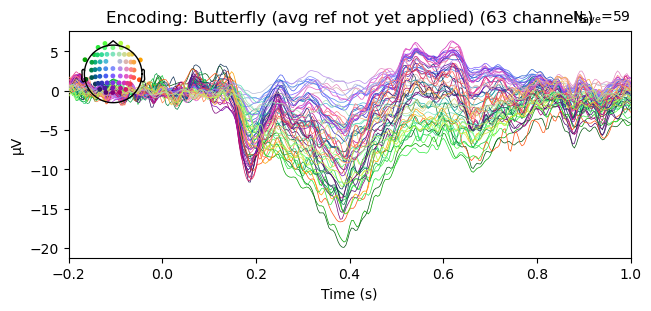

Channels with |z-scored variance| > 3: []


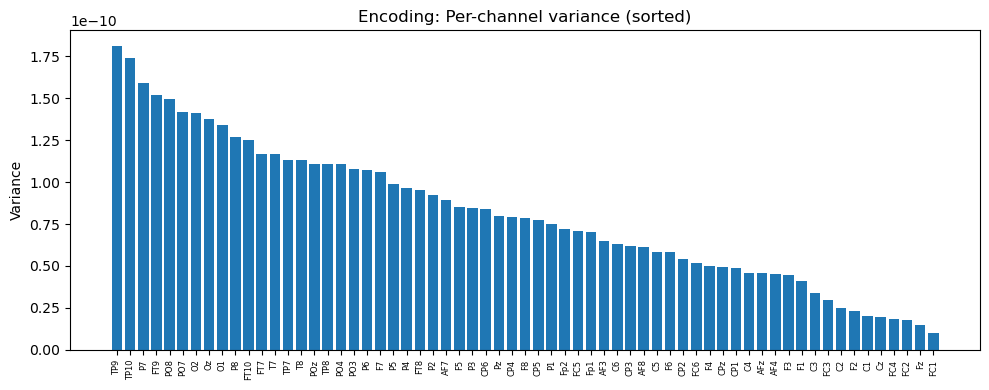


--- Retrieval ---
N epochs: 78
Interpolated channels (from earlier step): []


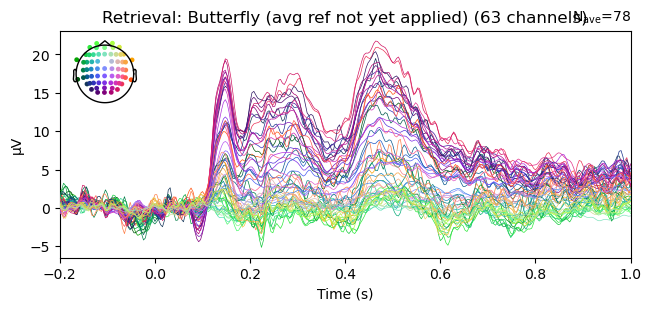

Channels with |z-scored variance| > 3: []


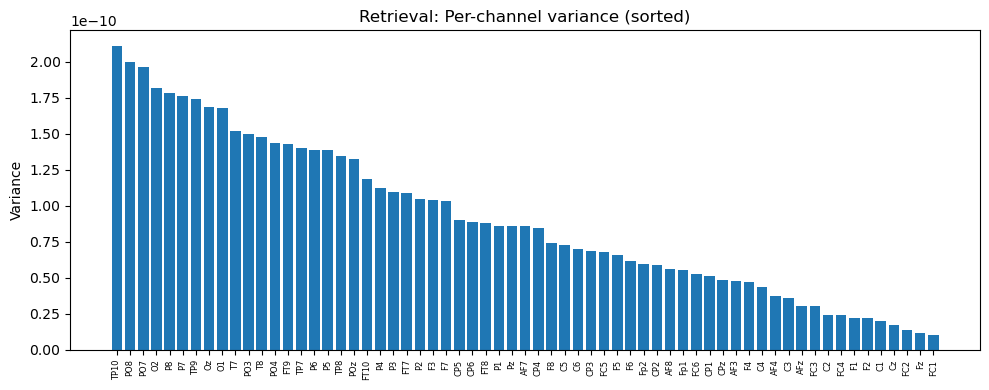

In [57]:
# ============================================================
# Schritt 10.5: Final Channel Inspection (post ICA, AR, baseline)
# ============================================================

import matplotlib.pyplot as plt

def inspect_final_channels(epochs, label=""):
    print(f"\n--- {label} ---")
    print(f"N epochs: {len(epochs)}")
    print(f"Interpolated channels (from earlier step): {epochs.info['bads']}")
    
    # Butterfly plot: quick eyeball for outlier channels
    evoked = epochs.average()
    evoked.plot(spatial_colors=True, titles=f"{label}: Butterfly (avg ref not yet applied)")
    
    # Per-channel variance across epochs — flags channels with
    # anomalously high/low variance relative to their neighbors
    data = epochs.get_data(picks="eeg")  # shape: n_epochs x n_channels x n_times
    ch_names = epochs.copy().pick("eeg").ch_names
    ch_var = data.var(axis=(0, 2))  # variance per channel, collapsed over epochs & time
    
    z_var = (ch_var - ch_var.mean()) / ch_var.std()
    suspicious = [ch_names[i] for i, z in enumerate(z_var) if abs(z) > 3]
    print(f"Channels with |z-scored variance| > 3: {suspicious}")
    
    # Visual: sorted variance per channel
    order = np.argsort(ch_var)[::-1]
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(ch_var)), ch_var[order])
    plt.xticks(range(len(ch_var)), [ch_names[i] for i in order], rotation=90, fontsize=6)
    plt.ylabel("Variance")
    plt.title(f"{label}: Per-channel variance (sorted)")
    plt.tight_layout()
    plt.show()
    
    return suspicious

susp_enc = inspect_final_channels(epochs_enc_clean, label="Encoding")
susp_ret = inspect_final_channels(epochs_ret_clean, label="Retrieval")

In [58]:
# ============================================================
# Schritt 11: Average Re-referencing
# ============================================================
# Apply identically to both encoding and retrieval sets.
# projection=True is standard for average ref (adds an SSP-style
# projector rather than hard-modifying data in place); with EEG
# reference it's applied immediately since data is already loaded.

epochs_enc_reref = epochs_enc_clean.copy().set_eeg_reference(
    ref_channels="average", projection=False
)

epochs_ret_reref = epochs_ret_clean.copy().set_eeg_reference(
    ref_channels="average", projection=False
)

# Sanity check: mean across channels should now be ~0 at every time point
for epo, label in [(epochs_enc_reref, "Encoding"), (epochs_ret_reref, "Retrieval")]:
    data = epo.get_data(picks="eeg")
    mean_across_ch = data.mean(axis=1)  # n_epochs x n_times
    print(f"{label}: max abs mean-across-channels = {np.abs(mean_across_ch).max():.2e}")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Encoding: max abs mean-across-channels = 1.38e-20
Retrieval: max abs mean-across-channels = 1.49e-20


C:\Users\noahm\AppData\Local\Temp\ipykernel_6112\795718127.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


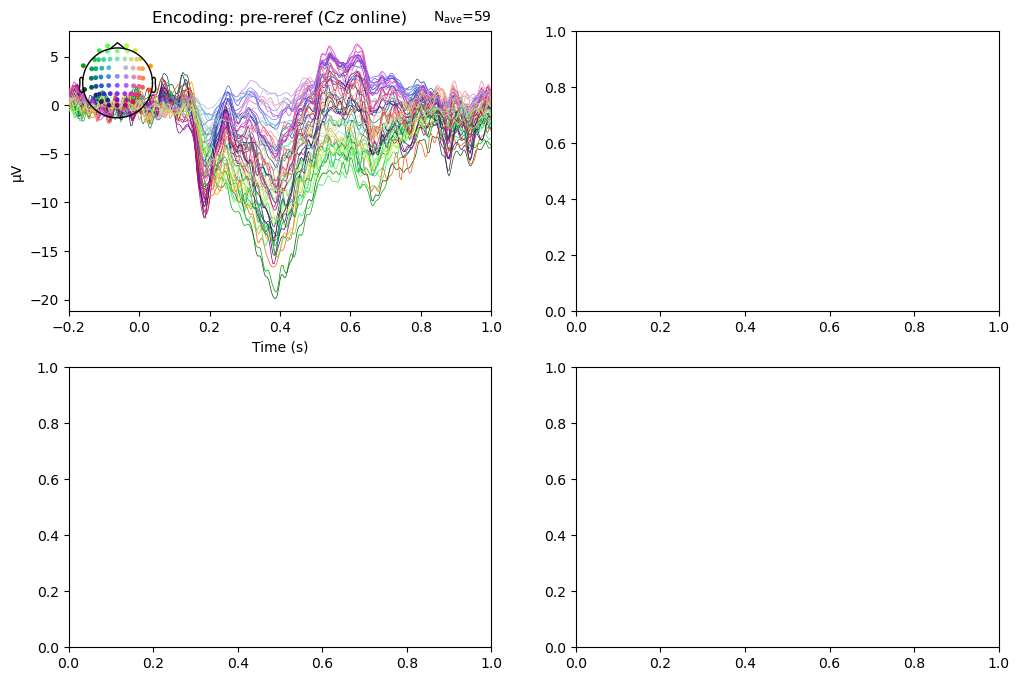

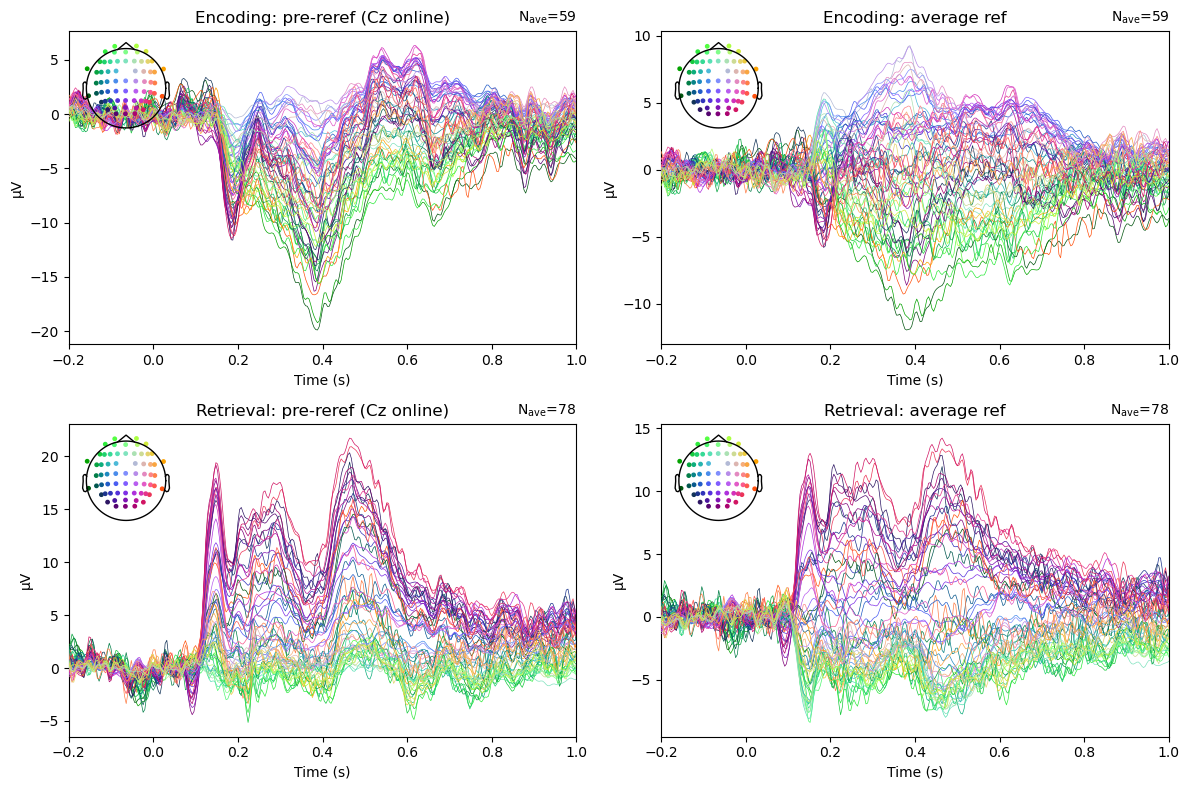

In [60]:
evoked_enc_reref = epochs_enc_reref.average()
evoked_ret_reref = epochs_ret_reref.average()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)

epochs_enc_clean.average().plot(spatial_colors=True, axes=axes[0, 0], show=False)
axes[0, 0].set_title("Encoding: pre-reref (Cz online)")

evoked_enc_reref.plot(spatial_colors=True, axes=axes[0, 1], show=False)
axes[0, 1].set_title("Encoding: average ref")

epochs_ret_clean.average().plot(spatial_colors=True, axes=axes[1, 0], show=False)
axes[1, 0].set_title("Retrieval: pre-reref (Cz online)")

evoked_ret_reref.plot(spatial_colors=True, axes=axes[1, 1], show=False)
axes[1, 1].set_title("Retrieval: average ref")

plt.tight_layout()
plt.show()

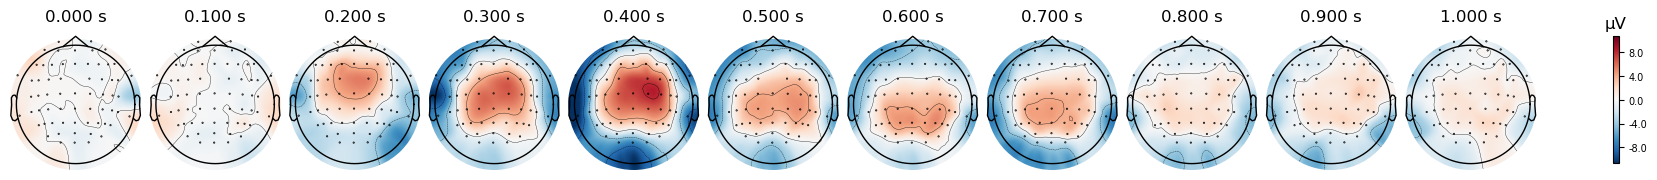

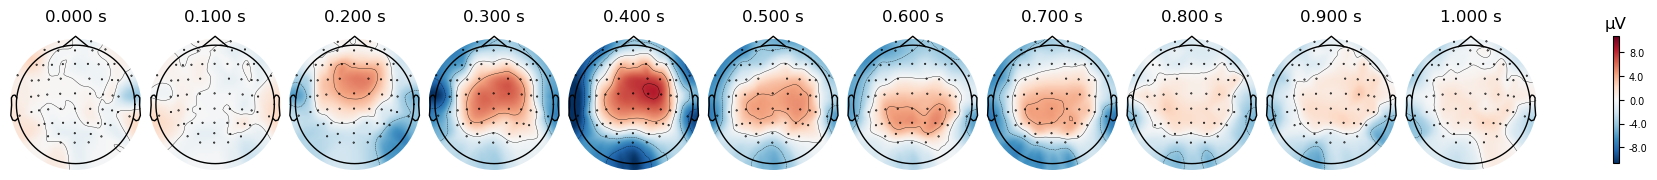

In [63]:
evoked_enc_reref.plot_topomap(times=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

In [66]:
# Output: cleaned recording
fname_enc_reref = (
    sub_dir
    / f"sub-{sub_number}_task-{task}_desc-encFinalAvgRef_eeg-epo.fif"
)

fname_ret_reref = (
    sub_dir
    / f"sub-{sub_number}_task-{task}_desc-retFinalAvgRef_eeg-epo.fif"
)

epochs_enc_reref.save(fname_enc_reref, overwrite=True)
epochs_ret_reref.save(fname_ret_reref, overwrite=True)

print(f"Encoding-Epochen gespeichert unter: {fname_enc_reref}")
print(f"Retrieval-Epochen gespeichert unter: {fname_ret_reref}")

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Encoding-Epochen gespeichert unter: C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_desc-encFinalAvgRef_eeg-epo.fif
Retrieval-Epochen gespeichert unter: C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_desc-retFinalAvgRef_eeg-epo.fif
